# 乗降研究の準備：離散更新と乱数

対応章：[30_agent_foundations.md](../chapters/30_agent_foundations.md)

小さな格子上の2人を1ステップだけ動かし，逐次更新と一斉更新の違いを確認する．続いて，同じ場所を希望する競合を乱数で解決し，1回の結果と反復結果を区別する．

## 初期配置

AとBは右向きに1セル進もうとする．初期状態ではAの右隣をBが占めている．逐次更新では前方のBから動かし，一斉更新では更新前の配置だけから移動可能性を判定する．

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

ROWS, COLS = 3, 5
initial_positions = {'A': (1, 1), 'B': (1, 2)}


def to_grid(positions):
    grid = np.zeros((ROWS, COLS), dtype=int)
    for label, (row, col) in positions.items():
        grid[row, col] = 1 if label == 'A' else 2
    return grid


def desired_cell(position):
    row, col = position
    return (row, min(col + 1, COLS - 1))

## 2種類の更新を比較する

逐次更新ではBを動かした結果をAが見るため，Aも前進できる．一斉更新ではAは更新前に占有されていたセルへ入らないため，その場で待つ．

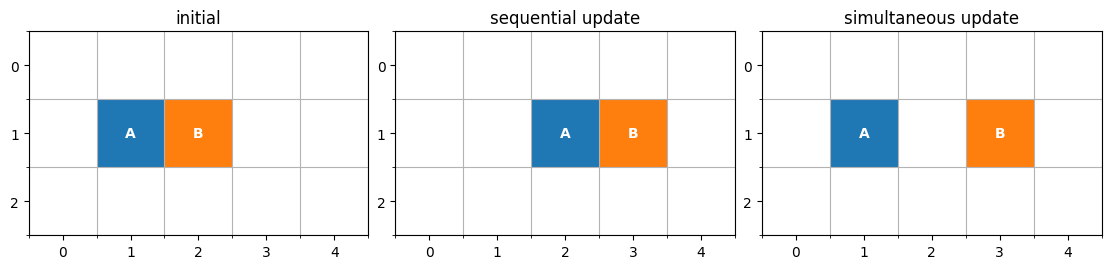

initial             : {'A': (1, 1), 'B': (1, 2)}
sequential update   : {'A': (1, 2), 'B': (1, 3)}
simultaneous update : {'A': (1, 1), 'B': (1, 3)}


In [2]:
def sequential_step(positions, order=('B', 'A')):
    new_positions = positions.copy()
    for label in order:
        target = desired_cell(new_positions[label])
        occupied = set(new_positions.values())
        if target not in occupied:
            new_positions[label] = target
    return new_positions


def simultaneous_step(positions):
    old_occupied = set(positions.values())
    proposals = {label: desired_cell(position) for label, position in positions.items()}
    new_positions = positions.copy()
    for label, target in proposals.items():
        if target not in old_occupied and list(proposals.values()).count(target) == 1:
            new_positions[label] = target
    return new_positions


sequential_positions = sequential_step(initial_positions)
simultaneous_positions = simultaneous_step(initial_positions)

states = [initial_positions, sequential_positions, simultaneous_positions]
titles = ['initial', 'sequential update', 'simultaneous update']
cmap = ListedColormap(['white', 'tab:blue', 'tab:orange'])

fig, axes = plt.subplots(1, 3, figsize=(11, 3), constrained_layout=True)
for ax, positions, title in zip(axes, states, titles):
    grid = to_grid(positions)
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    ax.set_title(title)
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which='minor', color='0.7')
    for label, (row, col) in positions.items():
        ax.text(col, row, label, ha='center', va='center', color='white', weight='bold')
plt.show()

for name, positions in zip(titles, states):
    assert len(set(positions.values())) == len(positions)
    print(f'{name:20s}: {positions}')

## 競合解決を反復する

AとBが同じ空きセルを希望すると仮定し，毎回どちらか1人を同確率で選ぶ．単独の試行ではAかBの一方しか観察できないが，反復すると選択割合を評価できる．

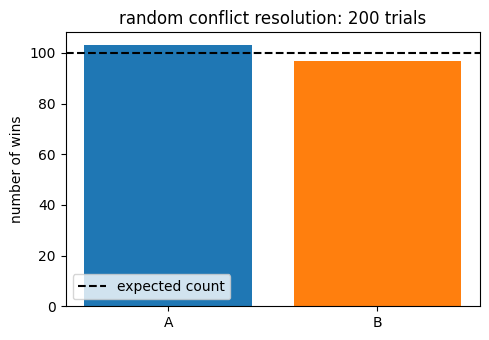

seed = 2026, A wins = 103, B wins = 97


In [3]:
seed = 2026
trials = 200
rng = np.random.default_rng(seed)
winners = rng.choice(['A', 'B'], size=trials)
counts = np.array([(winners == 'A').sum(), (winners == 'B').sum()])

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['A', 'B'], counts, color=['tab:blue', 'tab:orange'])
ax.axhline(trials / 2, color='black', linestyle='--', label='expected count')
ax.set_ylabel('number of wins')
ax.set_title(f'random conflict resolution: {trials} trials')
ax.legend()
plt.tight_layout()
plt.show()

print(f'seed = {seed}, A wins = {counts[0]}, B wins = {counts[1]}')

## 課題

1. 逐次更新の順序をA，Bの順へ変え，結果が変わる理由を説明する．
2. AとBの間に空きセルを1つ置き，2種類の更新結果が一致するか確認する．
3. trialsを10，100，1000と変え，Aの勝率が0.5へどのように近づくか記録する．
4. seedだけを変えた場合と，Aを選ぶ確率を0.7へ変えた場合の意味の違いを説明する．
5. 各更新後に人数保存と1セル1人を検査するassert文を追加する．